In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# Generación de datos simulados de clientes de una PYME
np.random.seed(42)

n_clientes = 200

data = {
    'cliente_id': range(1, n_clientes + 1),
    'recencia_dias': np.random.randint(1, 365, n_clientes),
    'frecuencia_compras': np.random.randint(1, 50, n_clientes),
    'monto_total_usd': np.round(np.random.exponential(150, n_clientes), 2),
    'num_productos': np.random.randint(1, 20, n_clientes)
}

df = pd.DataFrame(data)
print(f"✅ Dataset creado: {df.shape[0]} clientes, {df.shape[1]} variables")
df.head(10)

✅ Dataset creado: 200 clientes, 5 variables


,cliente_id,recencia_dias,frecuencia_compras,monto_total_usd,num_productos
0,1,103,2,240.14,5
1,2,349,3,157.46,4
2,3,271,49,181.58,3
3,4,107,37,238.29,19
4,5,72,49,331.10,18
5,6,189,17,61.87,15
6,7,21,49,70.64,9
7,8,103,2,14.80,17
8,9,122,2,129.51,14
9,10,215,28,5.49,15


In [3]:
# Análisis exploratorio básico
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe().round(2))
print("\n=== VALORES NULOS ===")
print(df.isnull().sum())

=== ESTADÍSTICAS DESCRIPTIVAS ===
       cliente_id  recencia_dias  frecuencia_compras  monto_total_usd  \
count      200.00         200.00              200.00           200.00   
mean       100.50         188.96               26.11           148.99   
std         57.88         104.67               14.19           148.56   
min          1.00           2.00                1.00             1.63   
25%         50.75          99.75               16.00            35.52   
50%        100.50         191.50               27.50           105.24   
75%        150.25         271.75               36.25           210.16   
max        200.00         364.00               49.00           743.52   

       num_productos  
count         200.00  
mean           10.26  
std             5.80  
min             1.00  
25%             5.00  
50%            11.00  
75%            15.00  
max            19.00  

=== VALORES NULOS ===
cliente_id            0
recencia_dias         0
frecuencia_compras    0
monto_

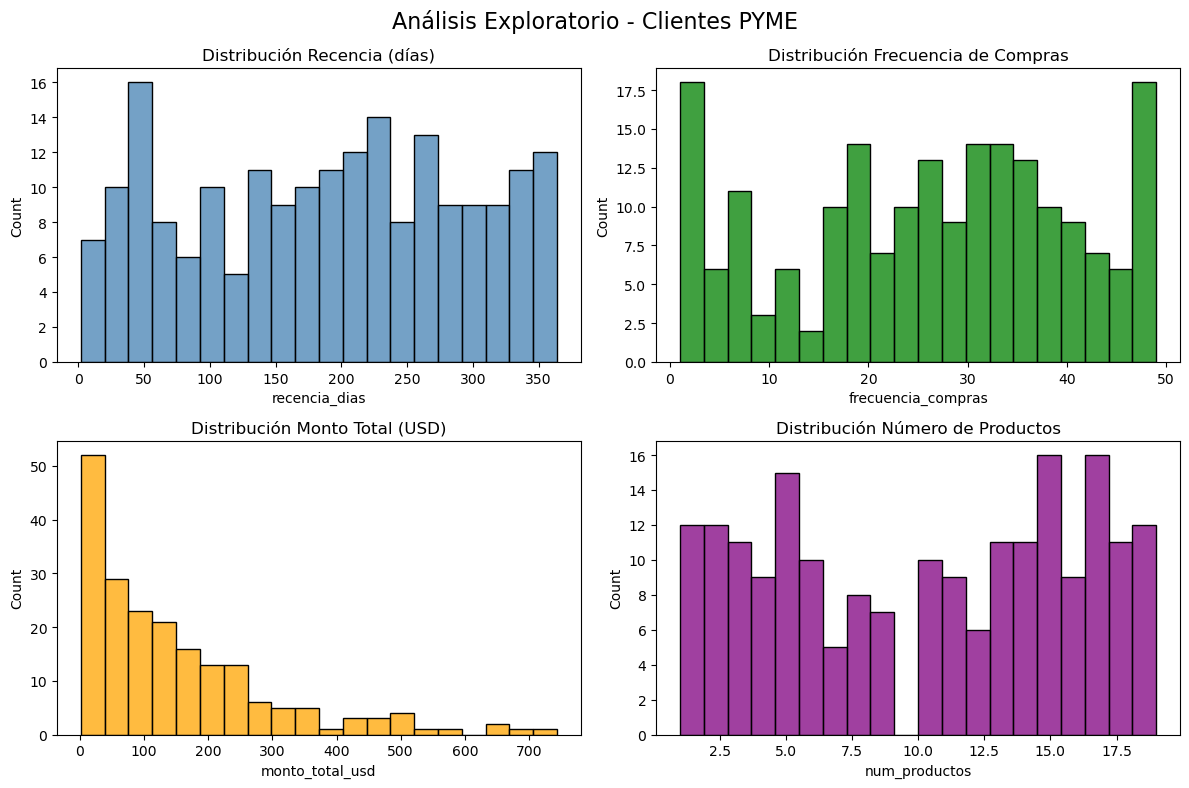

✅ Gráfico guardado como visualizacion_eda.png


In [4]:
# Visualización de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Análisis Exploratorio - Clientes PYME', fontsize=16)

sns.histplot(df['recencia_dias'], bins=20, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribución Recencia (días)')

sns.histplot(df['frecuencia_compras'], bins=20, ax=axes[0,1], color='green')
axes[0,1].set_title('Distribución Frecuencia de Compras')

sns.histplot(df['monto_total_usd'], bins=20, ax=axes[1,0], color='orange')
axes[1,0].set_title('Distribución Monto Total (USD)')

sns.histplot(df['num_productos'], bins=20, ax=axes[1,1], color='purple')
axes[1,1].set_title('Distribución Número de Productos')

plt.tight_layout()
plt.savefig('visualizacion_eda.png', dpi=150)
plt.show()
print("✅ Gráfico guardado como visualizacion_eda.png")

In [5]:
# Integración con base de datos SQLite
conn = sqlite3.connect('clientes_pyme.db')

df.to_sql('clientes', conn, if_exists='replace', index=False)

# Verificar que se guardó correctamente
query = pd.read_sql_query("SELECT COUNT(*) as total_clientes FROM clientes", conn)
print("✅ Base de datos creada: clientes_pyme.db")
print(query)

# Consulta de ejemplo
print("\n=== PRIMEROS 5 CLIENTES EN LA DB ===")
print(pd.read_sql_query("SELECT * FROM clientes LIMIT 5", conn))

✅ Base de datos creada: clientes_pyme.db
   total_clientes
0             200

=== PRIMEROS 5 CLIENTES EN LA DB ===
   cliente_id  recencia_dias  frecuencia_compras  monto_total_usd  \
0           1            103                   2           240.14   
1           2            349                   3           157.46   
2           3            271                  49           181.58   
3           4            107                  37           238.29   
4           5             72                  49           331.10   

   num_productos  
0              5  
1              4  
2              3  
3             19  
4             18  


In [6]:
# Preparación de datos y modelo K-Means
features = ['recencia_dias', 'frecuencia_compras', 'monto_total_usd', 'num_productos']
X = df[features]

# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar K-Means con 4 segmentos
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['segmento'] = kmeans.fit_predict(X_scaled)

# Resumen por segmento
resumen = df.groupby('segmento')[features].mean().round(2)
resumen['total_clientes'] = df.groupby('segmento').size()
print("✅ Segmentación completada")
print("\n=== PERFIL DE CADA SEGMENTO ===")
print(resumen)

✅ Segmentación completada

=== PERFIL DE CADA SEGMENTO ===
          recencia_dias  frecuencia_compras  monto_total_usd  num_productos  \
segmento                                                                      
0                246.85               18.93           102.04           4.69   
1                150.13               27.50           433.94          11.63   
2                151.19               39.97            95.35          10.87   
3                189.26               15.74            98.88          15.91   

          total_clientes  
segmento                  
0                     61  
1                     30  
2                     63  
3                     46  


AttributeError: module 'matplotlib.pyplot' has no attribute 'sa'

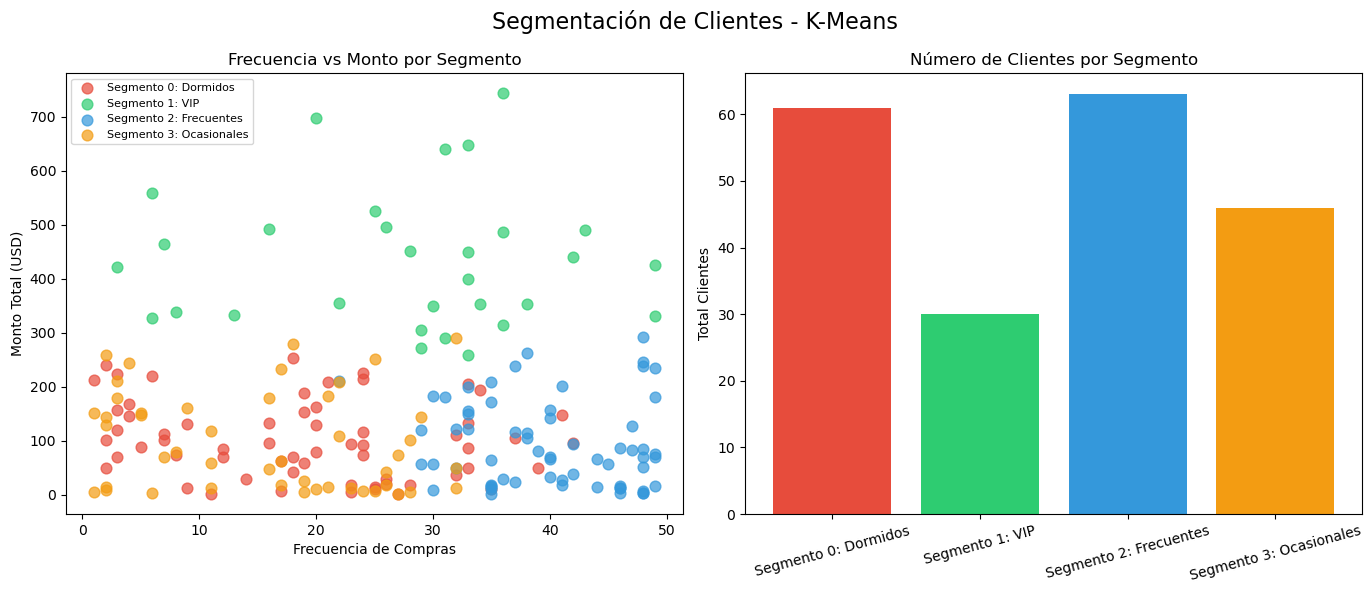

In [7]:
# Visualización de segmentos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Segmentación de Clientes - K-Means', fontsize=16)

colores = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
nombres = ['Segmento 0: Dormidos', 'Segmento 1: VIP', 'Segmento 2: Frecuentes', 'Segmento 3: Ocasionales']

# Gráfico 1: Frecuencia vs Monto
for i in range(4):
    mask = df['segmento'] == i
    axes[0].scatter(df[mask]['frecuencia_compras'], df[mask]['monto_total_usd'],
                   c=colores[i], label=nombres[i], alpha=0.7, s=60)
axes[0].set_xlabel('Frecuencia de Compras')
axes[0].set_ylabel('Monto Total (USD)')
axes[0].set_title('Frecuencia vs Monto por Segmento')
axes[0].legend(fontsize=8)

# Gráfico 2: Tamaño de segmentos
conteo = df['segmento'].value_counts().sort_index()
axes[1].bar(nombres, conteo.values, color=colores)
axes[1].set_title('Número de Clientes por Segmento')
axes[1].set_ylabel('Total Clientes')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.sa

In [8]:
# Guardar resultados con segmentos en la base de datos
df.to_sql('clientes_segmentados', conn, if_exists='replace', index=False)

# Consulta resumen final
print("=== RESUMEN FINAL EN BASE DE DATOS ===")
resumen_db = pd.read_sql_query("""
    SELECT segmento, 
           COUNT(*) as total,
           ROUND(AVG(recencia_dias), 1) as recencia_promedio,
           ROUND(AVG(frecuencia_compras), 1) as frecuencia_promedio,
           ROUND(AVG(monto_total_usd), 2) as monto_promedio
    FROM clientes_segmentados
    GROUP BY segmento
""", conn)
print(resumen_db)
conn.close()
print("\n✅ Base de datos actualizada y cerrada correctamente")

=== RESUMEN FINAL EN BASE DE DATOS ===
   segmento  total  recencia_promedio  frecuencia_promedio  monto_promedio
0         0     61              246.9                 18.9          102.04
1         1     30              150.1                 27.5          433.94
2         2     63              151.2                 40.0           95.35
3         3     46              189.3                 15.7           98.88

✅ Base de datos actualizada y cerrada correctamente
